In [1]:
import torch
import torch.nn as nn
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import torchvision.datasets as dataset
from torch.utils.data import DataLoader

In [2]:
mnist_dataset_train = dataset.MNIST('../DATA',train=True,download=True,transform=torchvision.transforms.ToTensor())
mnist_dataset_test = dataset.MNIST('../DATA',train=False,download=True,transform=torchvision.transforms.ToTensor())

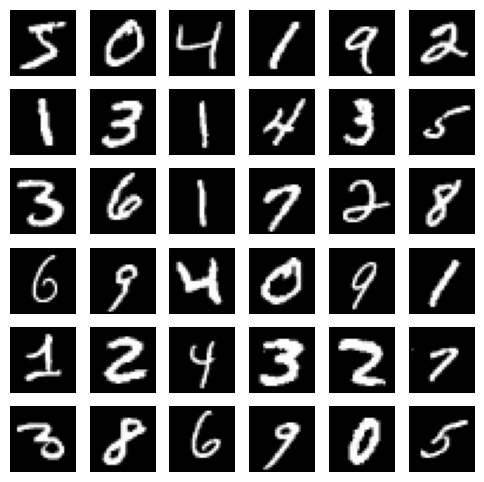

In [3]:
f, axs = plt.subplots(6, 6, figsize=(6, 6))
axs = axs.flatten()
for img, ax in zip(mnist_dataset_train.data[:36], axs):
    ax.imshow(img,cmap='gray')
    ax.set_axis_off()
plt.show()

In [4]:
N = 128
D = 28
T = 28
M = 128
L = 2
K = len(mnist_dataset_test.classes)

In [5]:
train_dataloader = DataLoader(mnist_dataset_train,shuffle=True,batch_size=128)
test_dataloader = DataLoader(mnist_dataset_test,shuffle=False,batch_size=128)

In [6]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [7]:
class LSTMModel(nn.Module):
    def __init__(self,input_size,hidden_size,num_layers,num_of_output,bidirectional=False):
        super().__init__()
        self.D = input_size
        self.M = hidden_size
        self.L = num_layers
        self.K = num_of_output
        self.bidirectional = bidirectional


        self.rnn = nn.LSTM(input_size=self.D,
                           hidden_size=self.M,
                           num_layers=self.L,
                           bidirectional=self.bidirectional,
                           batch_first=True)
        self.fc = nn.Linear(self.M,self.K)
    def forward(self,X):
        h0 = torch.zeros(self.L,X.size(0),self.M).to(device)
        c0 = torch.zeros(self.L,X.size(0),self.M).to(device)

        out,(h_n,c_n) = self.rnn(X,(h0,c0)) #NxTxM
        out = self.fc(out[:,-1,:])
        return out

In [8]:
model= LSTMModel(D,M,L,K)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())
lr_plat = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,'min',patience=10)

In [9]:
epochs = 10
train_loss = []
test_loss = []

In [10]:
for epoch in range(epochs):
    tmp_loss = []
    print(f'{epoch}/{epochs} start')

    for X,y in train_dataloader:
    

        X = X.view(-1, T, D)
        X = X.to(device)
        y = y.to(device)
        optimizer.zero_grad()
        y_hat = model(X)
        loss = criterion(y_hat,y)

        loss.backward()
        optimizer.step()
        # lr_plat.step(loss)

        tmp_loss.append(loss.item())
    print(f'{epoch}/{epochs} train  ended')
    train_loss.append( np.mean(tmp_loss))
    tmp_loss = []
    for X,y in test_dataloader:
        optimizer.zero_grad()

        X = X.view(-1,T,D)
        X = X.to(device)
        y = y.to(device)
        y_hat = model(X)
        loss = criterion(y_hat,y)


        tmp_loss.append(loss.item())
    print(f'{epoch}/{epochs} test  ended')
    test_loss.append(np.mean(tmp_loss))
    print(f'{epoch}/{epochs} train loss {train_loss[-1]} test loss {test_loss[-1]}')

0/10 start
0/10 train  ended
0/10 test  ended
0/10 train loss 0.5350505995597921 test loss 0.18881630629914092
1/10 start
1/10 train  ended
1/10 test  ended
1/10 train loss 0.13345424857125607 test loss 0.1131820677649937
2/10 start
2/10 train  ended
2/10 test  ended
2/10 train loss 0.08783075946774374 test loss 0.07627700169311388
3/10 start
3/10 train  ended
3/10 test  ended
3/10 train loss 0.06581418764696065 test loss 0.06859337607151063
4/10 start
4/10 train  ended
4/10 test  ended
4/10 train loss 0.051436901598898715 test loss 0.05287833787247397
5/10 start
5/10 train  ended
5/10 test  ended
5/10 train loss 0.042832726639991346 test loss 0.050640197673405794
6/10 start
6/10 train  ended
6/10 test  ended
6/10 train loss 0.0362151460260399 test loss 0.04791977615655647
7/10 start
7/10 train  ended
7/10 test  ended
7/10 train loss 0.032596515866417465 test loss 0.049776653012428784
8/10 start
8/10 train  ended
8/10 test  ended
8/10 train loss 0.028898811855438803 test loss 0.0423820

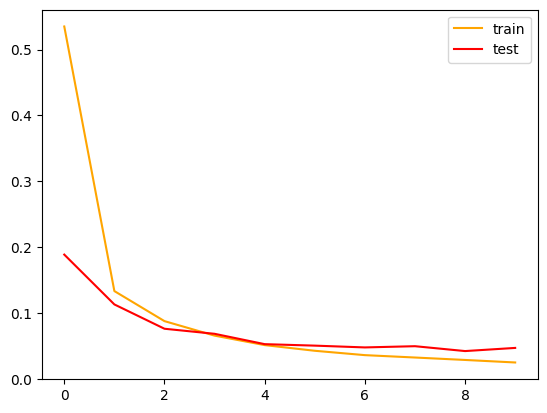

In [11]:
plt.plot(train_loss,color='orange',label='train')
plt.plot(test_loss,color='red',label='test')
plt.legend()
plt.show()

In [12]:
y_hats = []
ys = []
for X,y in mnist_dataset_test:
    X = X.view(-1,T,D)
    X = X.to(device)
    ys.append(y)
    y_hat = model(X)
    _, pred = torch.max(y_hat,1)
    with torch.no_grad():
        y_hats = np.concatenate((y_hats,pred.cpu().numpy()))

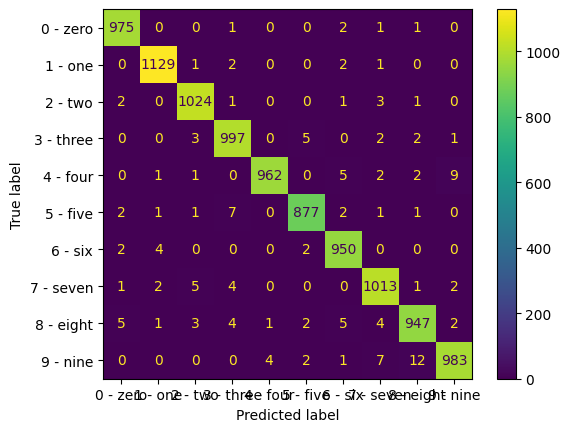

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay


ConfusionMatrixDisplay.from_predictions(ys,y_hats,display_labels=mnist_dataset_test.classes)

In [14]:
diffs = np.where(ys != y_hats)

In [15]:
diffs = diffs[0]
len(diffs)

143

4->6.0
9->8.0
2->7.0
5->3.0
9->8.0
5->3.0
3->5.0
8->2.0
4->8.0
7->3.0
8->2.0
2->7.0
2->3.0
4->9.0
1->3.0
8->6.0
3->5.0
6->5.0
8->1.0
7->3.0
3->9.0
4->6.0
8->9.0
6->5.0
7->2.0
9->5.0
7->1.0
5->7.0
8->3.0
8->3.0
8->7.0
4->6.0
9->8.0
8->0.0
9->7.0
8->0.0
5->2.0
2->8.0
8->3.0
5->0.0
7->2.0
5->3.0
4->9.0
4->1.0
2->0.0
8->6.0
3->7.0
9->8.0
4->9.0
6->1.0
4->9.0
1->7.0
3->5.0
9->6.0
3->2.0
4->9.0
2->0.0
2->6.0
5->8.0
5->3.0
9->5.0
6->1.0
9->8.0
9->8.0
4->9.0
8->0.0
3->7.0
5->1.0
9->7.0
9->8.0
9->7.0
1->2.0
7->8.0
7->9.0
6->1.0
6->0.0
4->9.0
4->8.0
6->0.0
8->0.0
7->0.0
8->2.0
7->2.0
4->6.0
9->4.0
1->3.0
4->6.0
7->9.0
8->6.0
9->7.0
9->7.0
9->4.0
5->6.0
9->4.0
4->9.0
3->2.0
3->2.0
8->7.0
8->9.0
6->1.0
8->7.0
9->4.0
8->4.0
8->6.0
1->6.0
8->0.0
3->5.0
5->3.0
3->8.0
3->8.0
3->5.0
9->8.0
9->8.0
9->8.0
9->8.0
8->7.0
4->7.0
9->7.0
7->1.0
0->7.0
8->3.0


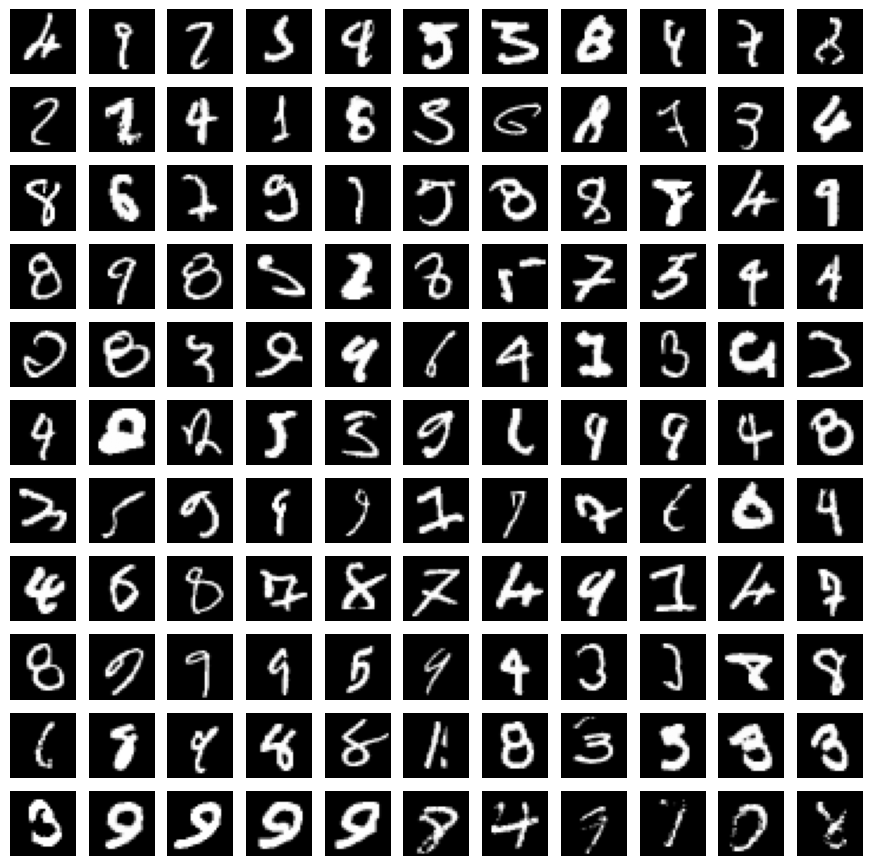

In [16]:
f,axes = plt.subplots(11,11,figsize=(11,11))
axes = axes.flatten()
for ax,i in zip(axes,diffs):
    ax.imshow(mnist_dataset_test.data[i],cmap='gray')
    ax.set_axis_off()
    print(f'{ys[i]}->{y_hats[i]}')